In [20]:
# Import required modules
import pandas as pd
import numpy as np
from statsmodels.formula.api import logit
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

In [21]:
# Read the dataset into a dataframe

insurance = pd.read_csv('car_insurance.csv')

# Exploratory analysis

print(insurance.info())
print(insurance['outcome'].value_counts())
print(insurance.isna().sum())
print(len(insurance['id'].unique())) #check for duplicates

for col in insurance: #check the type object columns
    if insurance[col].dtype =='object':
        print(insurance[col].value_counts(normalize=True))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   10000 non-null  int64  
 1   age                  10000 non-null  int64  
 2   gender               10000 non-null  int64  
 3   driving_experience   10000 non-null  object 
 4   education            10000 non-null  object 
 5   income               10000 non-null  object 
 6   credit_score         9018 non-null   float64
 7   vehicle_ownership    10000 non-null  float64
 8   vehicle_year         10000 non-null  object 
 9   married              10000 non-null  float64
 10  children             10000 non-null  float64
 11  postal_code          10000 non-null  int64  
 12  annual_mileage       9043 non-null   float64
 13  vehicle_type         10000 non-null  object 
 14  speeding_violations  10000 non-null  int64  
 15  duis                 10000 non-null  

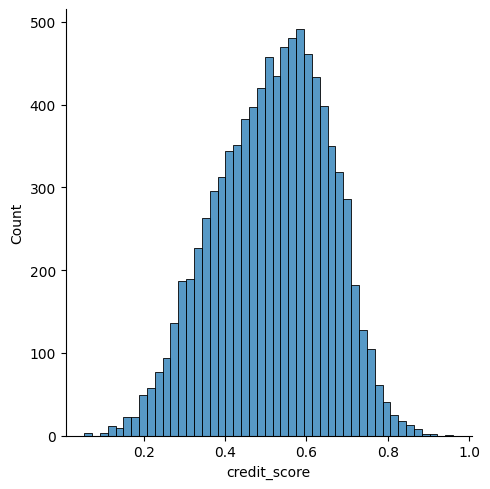

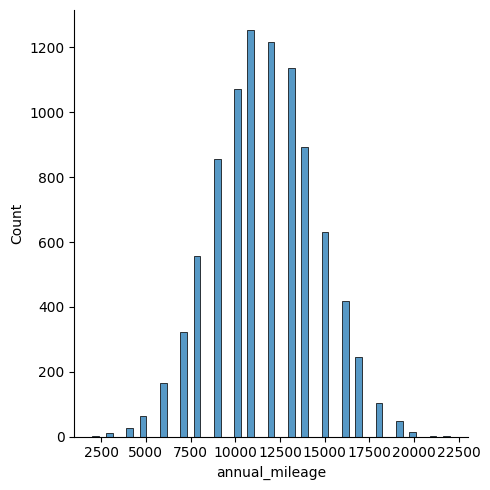

In [22]:
# Examine the distribution of credit_score and annual_mileage columns to determine imputation method
sns.displot(data=insurance, x='credit_score')
sns.displot(data=insurance, x='annual_mileage')

In [23]:
# Fill missing values in the credit_score and annual_mileage with the means due to normal distribution

cols_with_missing_values = insurance.columns[insurance.isna().sum() > 0]

for col in cols_with_missing_values:
    insurance[col].fillna(insurance[col].mean(), inplace=True)
    
print(insurance.isna().sum())

id                     0
age                    0
gender                 0
driving_experience     0
education              0
income                 0
credit_score           0
vehicle_ownership      0
vehicle_year           0
married                0
children               0
postal_code            0
annual_mileage         0
vehicle_type           0
speeding_violations    0
duis                   0
past_accidents         0
outcome                0
dtype: int64


In [24]:
# Clean the relevant columns in order to use the relevant visualizations

# Convert the target column to an integer
insurance['outcome'] = insurance['outcome'].astype(int)

# Convert the feature columns to integers


my_changes = {
              'driving_experience': {"0-9y":0,"10-19y":10,"20-29y":20,"30y+":30},
              'education': {'high school':0,'university':1,'none':2},
              'income':{'upper class':0,'middle class':1,'poverty':2,'working class':3},
              'vehicle_year': {'before 2015':0,'after 2015':1},
              'vehicle_type': {'sedan':0,'sports car':1}
              }


for col in insurance:
    if insurance[col].dtype =='object':
        if col in my_changes:
            insurance[col] = insurance[col].astype('category')
            insurance[col] = insurance[col].map(my_changes[col])
            insurance[col] = insurance[col].astype(int)
        print(insurance[col].value_counts(normalize=True))
    


print(insurance.info())


driving_experience
0     0.3530
10    0.3299
20    0.2119
30    0.1052
Name: proportion, dtype: float64
education
0    0.4157
1    0.3928
2    0.1915
Name: proportion, dtype: float64
income
0    0.4336
1    0.2138
2    0.1814
3    0.1712
Name: proportion, dtype: float64
vehicle_year
0    0.6967
1    0.3033
Name: proportion, dtype: float64
vehicle_type
0    0.9523
1    0.0477
Name: proportion, dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   10000 non-null  int64  
 1   age                  10000 non-null  int64  
 2   gender               10000 non-null  int64  
 3   driving_experience   10000 non-null  int64  
 4   education            10000 non-null  int64  
 5   income               10000 non-null  int64  
 6   credit_score         10000 non-null  float64
 7   vehicle_ownership    10000

In [28]:
# Create a logistic regression object for each column, calculate its conf_matrix and accuracy and store in a new dataframe objects

objects = pd.DataFrame(columns = ["column_name","object","pred_table","accuracy"])

for i in insurance.iloc[:,1:-1]: #skip columns id and outcome
    object1 = logit(f'outcome ~ {i}',data=insurance).fit()
    conf_matrix = object1.pred_table()
    TN = conf_matrix[0,0]
    TP = conf_matrix[1,1]
    FN = conf_matrix[1,0]
    FP = conf_matrix[0,1]
    accuracy = (TN+TP)/(TN+FN+FP+TP)
    row = pd.DataFrame({"column_name":[f'{i}'],
                        "object":[object1],
                        "pred_table":[conf_matrix],
                        "accuracy":[accuracy]})
    objects = pd.concat([objects, row], ignore_index=True)

objects = objects.sort_values('accuracy', ascending = False)
objects.reset_index(drop=True, inplace=True)
print(objects.head(5))

Optimization terminated successfully.
         Current function value: 0.511794
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.615951
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.467390
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.618880
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.558525
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.572557
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.552412
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.572668
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.586659
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.595431
  

In [29]:
# Find the highest accuracy

best_accuracy = objects["accuracy"].max()
max_index = objects["accuracy"].idxmax()
best_feature = objects.loc[max_index,'column_name']

print("The feature " + str(best_feature) + " has the highest accuracy of " + str(best_accuracy) + ".")

The feature driving_experience has the highest accuracy of 0.7771.


In [ ]:
# Store the result in a dataframe
best_feature_df = pd.DataFrame({'best_feature':[best_feature],'best_accuracy':[best_accuracy]})

In [ ]:
# My exploration (on top of the project's requirements)

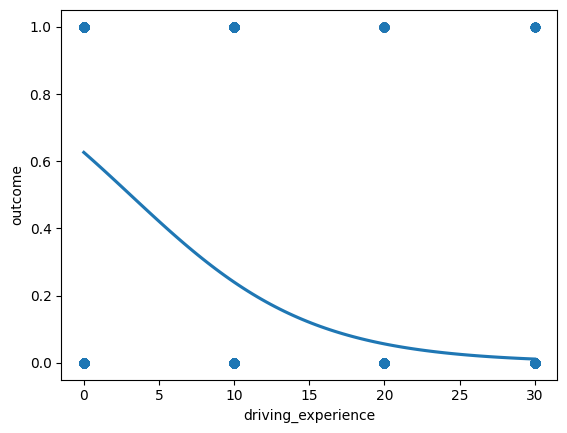

In [30]:
# Visualize the most accurate regression

sns.regplot(x='driving_experience',y='outcome',data = insurance, ci=None, logistic= True)
plt.show()

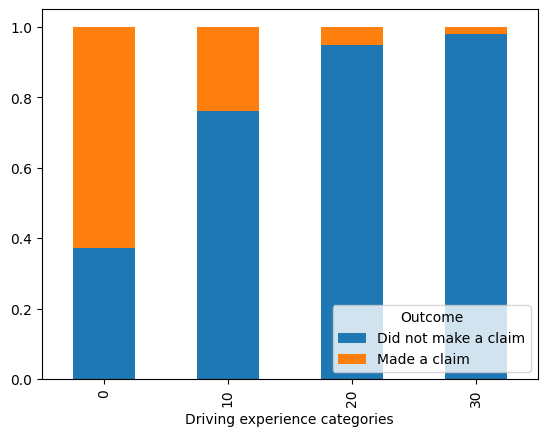

In [32]:
# Visualize the distribution of insurance claims among driving experience groups

props = insurance.groupby('driving_experience')['outcome'].value_counts(normalize=True)
wide_props = props.unstack()
wide_props.plot(kind="bar", stacked=True)
plt.legend(['Did not make a claim', 'Made a claim'], title="Outcome",loc='lower right')
plt.xlabel("Driving experience categories")


plt.show()


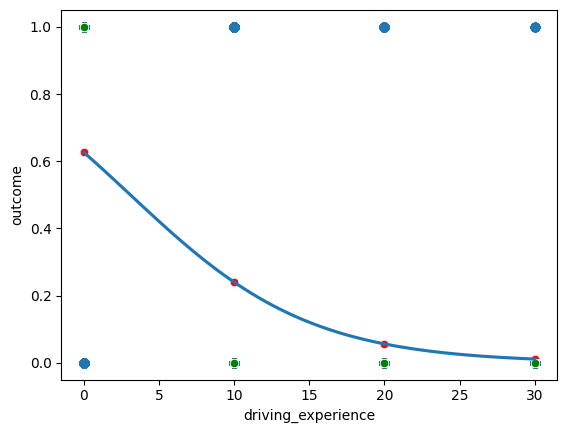

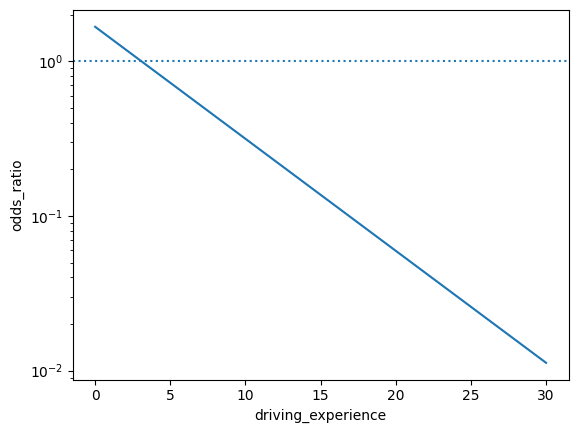

In [35]:
# Generate random data to run in the model

fictitious_data = pd.DataFrame({'driving_experience': np.random.choice([0, 10, 20, 30], size=10000)})

# Make predictions

driving_experience_model = objects.iloc[0,1]

prediction_data = fictitious_data.assign(
                  outcome = driving_experience_model.predict(fictitious_data))

sns.regplot(x='driving_experience',y='outcome',data = insurance, ci=None, logistic= True)
sns.scatterplot(x='driving_experience', y='outcome', data= prediction_data , color="red")

# Most likely outcome
prediction_data['most_likely_outcome'] = np.round(prediction_data['outcome'])
sns.scatterplot(x='driving_experience', y= 'most_likely_outcome', data = prediction_data, color='green')
plt.show()

# Odds ratio
prediction_data['odds_ratio'] = prediction_data['outcome'] /(1-prediction_data['outcome'])
sns.lineplot(x = 'driving_experience', y='odds_ratio', data = prediction_data)
plt.axhline(y=1, linestyle="dotted")
plt.yscale("log")

plt.show()